<a href="https://colab.research.google.com/github/omarmmowena10/DEPI-Tasks-/blob/main/DL_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Deep Learning Practical Assignment (Adult Income Dataset)

## 📌 Dataset
We will use the **Adult Income dataset** (also known as the Census Income dataset).  
The task is to predict whether a person earns **more than $50K/year** based on demographic and employment attributes.

---


In [ ]:
# Option 1: Using OpenML via scikit-learn
from sklearn.datasets import fetch_openml
import pandas as pd

# Load dataset from OpenML
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame

print(df.head())
print(df.shape)  # (48842, 15)

# Separate features and target
X = df.drop(columns="class")
y = df["class"]

   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

## Part 0: Data Preparation
1. Load the dataset into a DataFrame.
2. Split the data into **training, validation, and test sets**.  
   - Suggested: 70% training, 15% validation, 15% test.
3. Apply any necessary preprocessing:
   - Handle categorical features (encoding).
   - Scale numerical features if needed.
4. After training your models, always report results on:
   - **Training accuracy**
   - **Validation accuracy**
   - **Test accuracy**
5. At the end of the assignment, **compare all methods** across train, validation, and test sets.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [ ]:
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [ ]:
df.dropna(inplace=True)

print("Shape AFTER  cleaning:", df.shape)
print(f"Rows removed: {48842 - df.shape[0]}")
print(df.isna().sum())

Shape AFTER  cleaning: (45222, 15)
Rows removed: 3620
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64


In [ ]:

df = df.drop("education", axis=1)

df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)


In [81]:
from sklearn.preprocessing import LabelEncoder

lX = pd.get_dummies(X)

print("Encoding done")
print(X.head())
print(f"Shape after encoding: {X.shape}")

Encoding done
   age  workclass  fnlwgt  education-num  marital-status  occupation  \
0   25          2  226802              7               4           6   
1   38          2   89814              9               2           4   
2   28          1  336951             12               2          10   
3   44          2  160323             10               2           6   
5   34          2  198693              6               4           7   

   relationship  race  sex  capital-gain  capital-loss  hours-per-week  \
0             3     2    1             0             0              40   
1             0     4    1             0             0              50   
2             0     4    1             0             0              40   
3             0     2    1          7688             0              40   
5             1     4    1             0             0              30   

   native-country  
0              38  
1              38  
2              38  
3              38  
5       

In [ ]:
y = (y.astype(str).str.strip() == ">50K").astype(int)

print("Target after conversion:")
print(y.value_counts())
print()
print("0 = earns <=50K")
print("1 = earns  >50K")

Target after conversion:
class
0    34014
1    11208
Name: count, dtype: int64

0 = earns <=50K
1 = earns  >50K


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

In [ ]:
numerical_cols = ["age", "fnlwgt", "education-num", "capital-gain",
                  "capital-loss", "hours-per-week"]

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Data preparation done!")
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Data preparation done!
Train shape: (31655, 13)
Validation shape: (6783, 13)
Test shape: (6784, 13)


In [ ]:
print(df.head())

   age  workclass  fnlwgt  education-num      marital-status  \
0   25    Private  226802              7       Never-married   
1   38    Private   89814              9  Married-civ-spouse   
2   28  Local-gov  336951             12  Married-civ-spouse   
3   44    Private  160323             10  Married-civ-spouse   
5   34    Private  198693              6       Never-married   

          occupation   relationship   race   sex  capital-gain  capital-loss  \
0  Machine-op-inspct      Own-child  Black  Male             0             0   
1    Farming-fishing        Husband  White  Male             0             0   
2    Protective-serv        Husband  White  Male             0             0   
3  Machine-op-inspct        Husband  Black  Male          7688             0   
5      Other-service  Not-in-family  White  Male             0             0   

   hours-per-week native-country  class  
0              40  United-States  <=50K  
1              50  United-States  <=50K  
2       

In [44]:
print(X_train.dtypes)
print(y_train.dtype)

age               float32
workclass         float32
fnlwgt            float32
education-num     float32
marital-status    float32
occupation        float32
relationship      float32
race              float32
sex               float32
capital-gain      float32
capital-loss      float32
hours-per-week    float32
native-country    float32
dtype: object
category


In [45]:

y_train = y_train.cat.codes.astype(np.float32)
y_val   = y_val.cat.codes.astype(np.float32)

In [54]:
y_test = y_test.cat.codes.astype(np.float32)

In [46]:
print(y_train.dtype)
print(np.unique(y_train))

float32
[0. 1.]



## Part 1: Optimizers
1. Train the same neural network using:
   - Stochastic Gradient Descent (SGD)
   - SGD with Momentum
   - Adam
2. Compare the training and validation accuracy for each optimizer.
3. Which optimizer converges the fastest? Which gives the best generalization?
4. Explain *why* Adam often performs better than plain SGD.

---


In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def build_model():
    model = Sequential([
        Input(shape=(13,)),

        Dense(64, activation='relu'),

        Dense(32, activation='relu'),

        Dense(1, activation='sigmoid')
    ])
    return model

model = build_model()
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

Stochastic Gradient Descent (SGD)

In [49]:
model_sgd= build_model()

model_sgd.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7412 - loss: 0.5778 - val_accuracy: 0.7138 - val_loss: 0.5210
Epoch 2/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7933 - loss: 0.4289 - val_accuracy: 0.7871 - val_loss: 0.4526
Epoch 3/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8110 - loss: 0.3975 - val_accuracy: 0.7851 - val_loss: 0.4753
Epoch 4/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8100 - loss: 0.3937 - val_accuracy: 0.7346 - val_loss: 0.5080
Epoch 5/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8191 - loss: 0.3789 - val_accuracy: 0.8324 - val_loss: 0.3500
Epoch 6/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8206 - loss: 0.3686 - val_accuracy: 0.8328 - val_loss: 0.3522
Epoch 7/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8223 - loss: 0.3680 - val_accuracy: 0.7912 - val_loss: 0.4567
Epoch 8/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8212 - loss: 0.3677 - val_accuracy: 0.

### SGD with Momentum

In [50]:
from tensorflow.keras.optimizers import SGD

model_sgd_mom = build_model()

model_sgd_mom.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_sgd_mom = model_sgd_mom.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7605 - loss: 0.5571 - val_accuracy: 0.8061 - val_loss: 0.4338
Epoch 2/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7963 - loss: 0.4354 - val_accuracy: 0.8167 - val_loss: 0.4024
Epoch 3/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7968 - loss: 0.4289 - val_accuracy: 0.8036 - val_loss: 0.4207
Epoch 4/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7962 - loss: 0.4312 - val_accuracy: 0.8010 - val_loss: 0.4213
Epoch 5/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8018 - loss: 0.4260 - val_accuracy: 0.8159 - val_loss: 0.3927
Epoch 6/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8095 - loss: 0.4059 - val_accuracy: 0.8243 - val_loss: 0.3801
Epoch 7/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8146 - loss: 0.3932 - val_accuracy: 0.8268 - val_loss: 0.3769
Epoch 8/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8189 - loss: 0.3808 - val_accuracy: 0.

### Adam

In [51]:
model_adam = build_model()

model_adam.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_adam = model_adam.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7926 - loss: 0.4513 - val_accuracy: 0.8371 - val_loss: 0.3449
Epoch 2/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8314 - loss: 0.3535 - val_accuracy: 0.8433 - val_loss: 0.3361
Epoch 3/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8352 - loss: 0.3489 - val_accuracy: 0.8461 - val_loss: 0.3287
Epoch 4/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8381 - loss: 0.3420 - val_accuracy: 0.8464 - val_loss: 0.3302
Epoch 5/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8363 - loss: 0.3416 - val_accuracy: 0.8452 - val_loss: 0.3267
Epoch 6/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8366 - loss: 0.3413 - val_accuracy: 0.8436 - val_loss: 0.3360
Epoch 7/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8454 - loss: 0.3303 - val_accuracy: 0.8459 - val_loss: 0.3248
Epoch 8/30
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8424 - loss: 0.3389 - val_accuracy: 0.

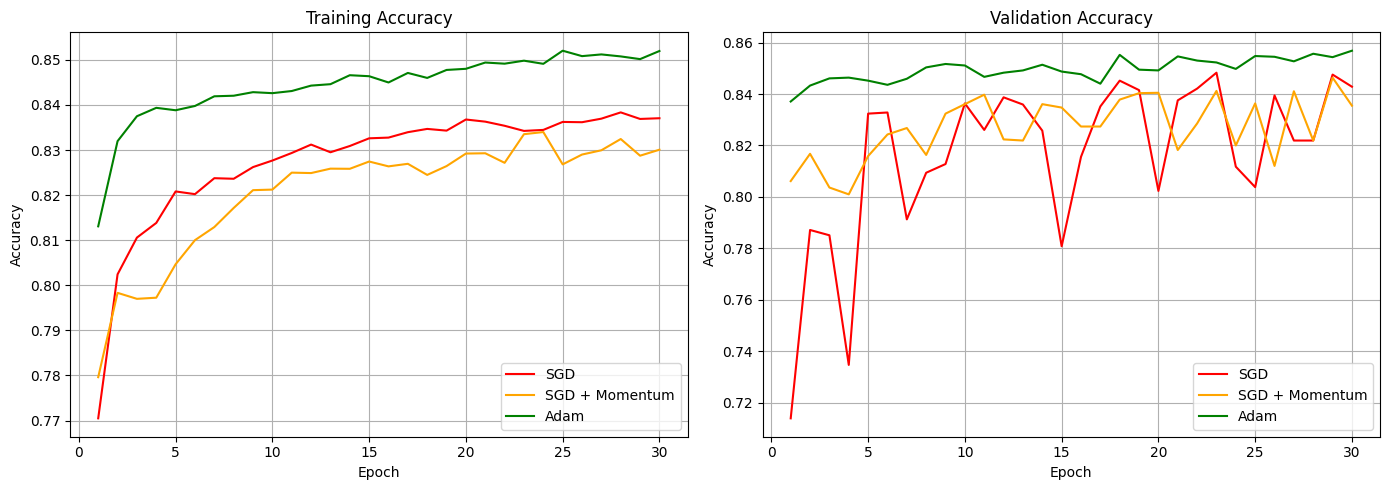

In [52]:
import matplotlib.pyplot as plt

epochs = range(1, 31)

plt.figure(figsize=(14, 5))

# --- Training Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history_sgd.history['accuracy'],     label='SGD',             color='red')
plt.plot(epochs, history_sgd_mom.history['accuracy'], label='SGD + Momentum',  color='orange')
plt.plot(epochs, history_adam.history['accuracy'],    label='Adam',            color='green')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history_sgd.history['val_accuracy'],     label='SGD',            color='red')
plt.plot(epochs, history_sgd_mom.history['val_accuracy'], label='SGD + Momentum', color='orange')
plt.plot(epochs, history_adam.history['val_accuracy'],    label='Adam',           color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [55]:
loss_sgd,     acc_sgd     = model_sgd.evaluate(X_test, y_test, verbose=0)
loss_sgd_mom, acc_sgd_mom = model_sgd_mom.evaluate(X_test, y_test, verbose=0)
loss_adam,    acc_adam    = model_adam.evaluate(X_test, y_test, verbose=0)

train_sgd     = history_sgd.history['accuracy'][-1]
train_sgd_mom = history_sgd_mom.history['accuracy'][-1]
train_adam    = history_adam.history['accuracy'][-1]

val_sgd     = history_sgd.history['val_accuracy'][-1]
val_sgd_mom = history_sgd_mom.history['val_accuracy'][-1]
val_adam    = history_adam.history['val_accuracy'][-1]

print("=" * 55)
print(f"{'Optimizer':<20} {'Train':>10} {'Val':>10} {'Test':>10}")
print("=" * 55)
print(f"{'SGD':<20} {train_sgd:>10.4f} {val_sgd:>10.4f} {acc_sgd:>10.4f}")
print(f"{'SGD + Momentum':<20} {train_sgd_mom:>10.4f} {val_sgd_mom:>10.4f} {acc_sgd_mom:>10.4f}")
print(f"{'Adam':<20} {train_adam:>10.4f} {val_adam:>10.4f} {acc_adam:>10.4f}")
print("=" * 55)

Optimizer                 Train        Val       Test
SGD                      0.8371     0.8428     0.8408
SGD + Momentum           0.8301     0.8355     0.8320
Adam                     0.8520     0.8568     0.8523


**Why does Adam perform better in training?**

Adam automatically adjusts the learning rate for each parameter — it learns fast where needed and slows down where needed. Plain SGD uses the same fixed learning rate for everything


|                      | SGD        | SGD + Momentum    | Adam       |
| -------------------- | ---------- | ----------------- | ---------- |
| Convergence speed    |  Slowest |  Medium         |  Fastest |
| Final train accuracy | Lowest     | Medium            | Highest    |
| Generalization (val) |  Stable   |  Slightly worse |  Good     |

## Part 2: Batch Size
1. Train the same model with different batch sizes (e.g., 1, 32, 128, 1024).
2. Compare:
   - Training speed
   - Validation accuracy
   - Test accuracy
   - Generalization ability
3. Which batch size leads to the **noisiest gradient updates**?
4. Which batch size generalizes better and why?

In [56]:
import time

model_bs1 = build_model()
model_bs1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()

history_bs1 = model_bs1.fit(
    X_train, y_train,
    epochs=10,
    batch_size=1,
    validation_data=(X_val, y_val),
    verbose=1
)

time_bs1 = time.time() - start
print(f"\nTraining time: {time_bs1:.1f} seconds")

Epoch 1/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 77s 2ms/step - accuracy: 0.7985 - loss: 0.4283 - val_accuracy: 0.8453 - val_loss: 0.3383
Epoch 2/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 68s 2ms/step - accuracy: 0.8354 - loss: 0.3494 - val_accuracy: 0.8462 - val_loss: 0.3268
Epoch 3/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 68s 2ms/step - accuracy: 0.8395 - loss: 0.3465 - val_accuracy: 0.8371 - val_loss: 0.3427
Epoch 4/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 68s 2ms/step - accuracy: 0.8397 - loss: 0.3397 - val_accuracy: 0.8371 - val_loss: 0.3393
Epoch 5/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 67s 2ms/step - accuracy: 0.8406 - loss: 0.3410 - val_accuracy: 0.8458 - val_loss: 0.3233
Epoch 6/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 67s 2ms/step - accuracy: 0.8415 - loss: 0.3364 - val_accuracy: 0.8496 - val_loss: 0.3273
Epoch 7/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 66s 2ms/step - accuracy: 0.8434 - loss: 0.3332 - val_accuracy: 0.8451 - val_loss: 0.3346
Epoch 8/10
31655/31655 ━━━━━━━━━━━━━━━━━━━━ 79s 2ms/step - accuracy: 

In [57]:
model_bs32 = build_model()
model_bs32.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()

history_bs32 = model_bs32.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

time_bs32 = time.time() - start
print(f"Batch size 32 done")
print(f"Training time   : {time_bs32:.1f} seconds")
print(f"Final Train Acc : {history_bs32.history['accuracy'][-1]:.4f}")
print(f"Final Val Acc   : {history_bs32.history['val_accuracy'][-1]:.4f}")

Epoch 1/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7892 - loss: 0.4495 - val_accuracy: 0.8226 - val_loss: 0.3769
Epoch 2/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8374 - loss: 0.3490 - val_accuracy: 0.8397 - val_loss: 0.3391
Epoch 3/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8345 - loss: 0.3458 - val_accuracy: 0.8446 - val_loss: 0.3284
Epoch 4/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8355 - loss: 0.3506 - val_accuracy: 0.8458 - val_loss: 0.3286
Epoch 5/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8380 - loss: 0.3425 - val_accuracy: 0.8262 - val_loss: 0.3573
Epoch 6/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8364 - loss: 0.3453 - val_accuracy: 0.8496 - val_loss: 0.3310
Epoch 7/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8378 - loss: 0.3403 - val_accuracy: 0.8402 - val_loss: 0.3384
Epoch 8/10
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8411 - loss: 0.3367 - val_accuracy: 0.

In [58]:
model_bs128 = build_model()
model_bs128.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()

history_bs128 = model_bs128.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)

time_bs128 = time.time() - start
print(f"Batch size 128 done")
print(f"Training time   : {time_bs128:.1f} seconds")
print(f"Final Train Acc : {history_bs128.history['accuracy'][-1]:.4f}")
print(f"Final Val Acc   : {history_bs128.history['val_accuracy'][-1]:.4f}")

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7569 - loss: 0.6069 - val_accuracy: 0.8195 - val_loss: 0.3911
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8185 - loss: 0.3930 - val_accuracy: 0.8252 - val_loss: 0.3758
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8278 - loss: 0.3642 - val_accuracy: 0.8372 - val_loss: 0.3450
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8346 - loss: 0.3512 - val_accuracy: 0.8367 - val_loss: 0.3481
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8351 - loss: 0.3472 - val_accuracy: 0.8449 - val_loss: 0.3315
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8346 - loss: 0.3471 - val_accuracy: 0.8477 - val_loss: 0.3301
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8414 - loss: 0.3375 - val_accuracy: 0.8476 - val_loss: 0.3275
Epoch 8/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8386 - loss: 0.3403 - val_accuracy: 0.

In [59]:
model_bs1024 = build_model()
model_bs1024.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start = time.time()

history_bs1024 = model_bs1024.fit(
    X_train, y_train,
    epochs=10,
    batch_size=1024,
    validation_data=(X_val, y_val),
    verbose=1
)

time_bs1024 = time.time() - start
print(f"Batch size 1024 done")
print(f"Training time   : {time_bs1024:.1f} seconds")
print(f"Final Train Acc : {history_bs1024.history['accuracy'][-1]:.4f}")
print(f"Final Val Acc   : {history_bs1024.history['val_accuracy'][-1]:.4f}")

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.4500 - loss: 1.9938 - val_accuracy: 0.7654 - val_loss: 0.5105
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7660 - loss: 0.5052 - val_accuracy: 0.7719 - val_loss: 0.4678
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7701 - loss: 0.4658 - val_accuracy: 0.7851 - val_loss: 0.4464
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7823 - loss: 0.4530 - val_accuracy: 0.7951 - val_loss: 0.4331
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7944 - loss: 0.4366 - val_accuracy: 0.8061 - val_loss: 0.4199
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8086 - loss: 0.4215 - val_accuracy: 0.8138 - val_loss: 0.4057
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8149 - loss: 0.4053 - val_accuracy: 0.8254 - val_loss: 0.3927
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8214 - loss: 0.3926 - val_accuracy: 0.8278 - val

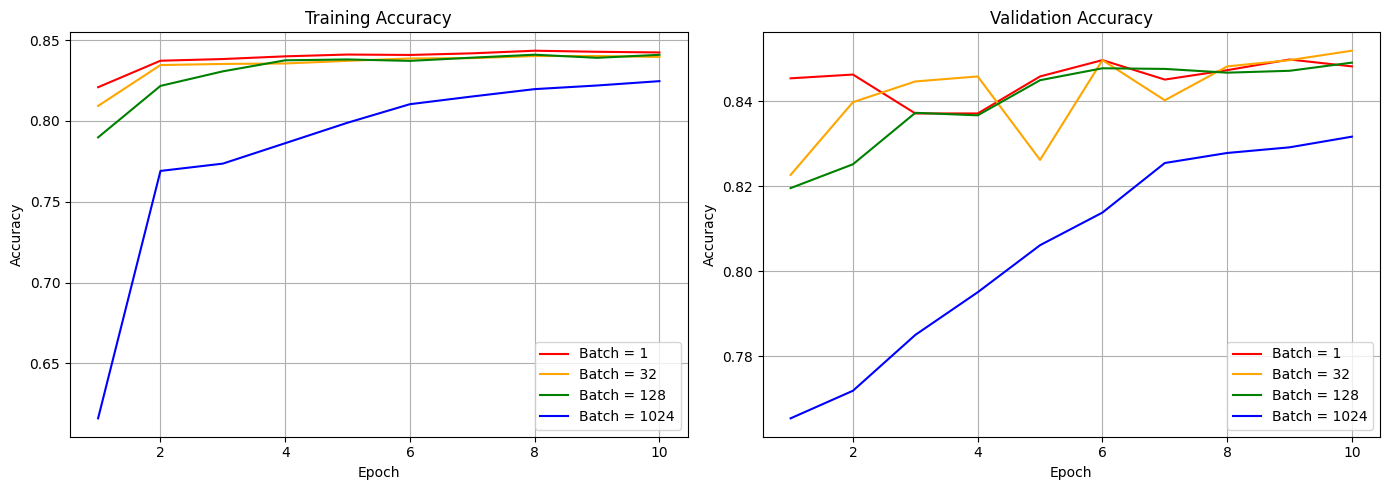

In [60]:
epochs = range(1, 11)

plt.figure(figsize=(14, 5))

# --- Training Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history_bs1.history['accuracy'],    label='Batch = 1',    color='red')
plt.plot(epochs, history_bs32.history['accuracy'],   label='Batch = 32',   color='orange')
plt.plot(epochs, history_bs128.history['accuracy'],  label='Batch = 128',  color='green')
plt.plot(epochs, history_bs1024.history['accuracy'], label='Batch = 1024', color='blue')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history_bs1.history['val_accuracy'],    label='Batch = 1',    color='red')
plt.plot(epochs, history_bs32.history['val_accuracy'],   label='Batch = 32',   color='orange')
plt.plot(epochs, history_bs128.history['val_accuracy'],  label='Batch = 128',  color='green')
plt.plot(epochs, history_bs1024.history['val_accuracy'], label='Batch = 1024', color='blue')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [61]:

_, acc_bs1    = model_bs1.evaluate(X_test,   y_test, verbose=0)
_, acc_bs32   = model_bs32.evaluate(X_test,  y_test, verbose=0)
_, acc_bs128  = model_bs128.evaluate(X_test, y_test, verbose=0)
_, acc_bs1024 = model_bs1024.evaluate(X_test,y_test, verbose=0)


train_bs1    = history_bs1.history['accuracy'][-1]
train_bs32   = history_bs32.history['accuracy'][-1]
train_bs128  = history_bs128.history['accuracy'][-1]
train_bs1024 = history_bs1024.history['accuracy'][-1]

val_bs1    = history_bs1.history['val_accuracy'][-1]
val_bs32   = history_bs32.history['val_accuracy'][-1]
val_bs128  = history_bs128.history['val_accuracy'][-1]
val_bs1024 = history_bs1024.history['val_accuracy'][-1]


print("=" * 65)
print(f"{'Batch Size':<12} {'Train':>10} {'Val':>10} {'Test':>10} {'Time(s)':>10}")
print("=" * 65)
print(f"{'1':<12} {train_bs1:>10.4f} {val_bs1:>10.4f} {acc_bs1:>10.4f} {time_bs1:>10.1f}")
print(f"{'32':<12} {train_bs32:>10.4f} {val_bs32:>10.4f} {acc_bs32:>10.4f} {time_bs32:>10.1f}")
print(f"{'128':<12} {train_bs128:>10.4f} {val_bs128:>10.4f} {acc_bs128:>10.4f} {time_bs128:>10.1f}")
print(f"{'1024':<12} {train_bs1024:>10.4f} {val_bs1024:>10.4f} {acc_bs1024:>10.4f} {time_bs1024:>10.1f}")
print("=" * 65)

Batch Size        Train        Val       Test    Time(s)
1                0.8423     0.8481     0.8448      693.8
32               0.8396     0.8518     0.8464       27.1
128              0.8409     0.8490     0.8445       11.8
1024             0.8246     0.8316     0.8274        7.7


| Batch Size | Speed   | Noise       | Generalization       |
| ---------- | ------- | ----------- | -------------------- |
| 1          |  682s |  Highest  |  Good but unstable  |
| 32         |  28s   |  Moderate |  Best balance       |
| 128        |  9.9s  |  Low      |  Good               |
| 1024       |  3.3s |  Lowest   |  Needs more epochs |

Noisiest gradient updates → Batch size = 1 (one sample per update)

Best generalization → Batch size = 32 (good balance between noise and stability)


## Part 3: Overfitting and Regularization
1. Train a large neural network (many parameters) on the dataset.
2. Observe training vs. validation accuracy.  
   - Do you see signs of overfitting?
3. Apply regularization techniques:
   - **L2 regularization**
   - **Dropout**
4. Compare the validation results before and after regularization.
5. Which regularization method was more effective in reducing overfitting? Why?

---


In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def build_large_model():
    model = Sequential([
        Input(shape=(13,)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(1,   activation='sigmoid')
    ])
    return model

model_no_reg = build_large_model()
model_no_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Large model summary:")
model_no_reg.summary()

Large model summary:


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                │ (None, 512)            │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,713 (702.00 KB)

 Trainable params: 179,713 (702.00 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
history_no_reg = model_no_reg.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

print("Training done")
print(f"Final Train Acc : {history_no_reg.history['accuracy'][-1]:.4f}")
print(f"Final Val Acc   : {history_no_reg.history['val_accuracy'][-1]:.4f}")
gap = history_no_reg.history['accuracy'][-1] - history_no_reg.history['val_accuracy'][-1]
print(f"Gap (Train-Val) : {gap:.4f}  ← overfitting indicator")

Epoch 1/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7895 - loss: 0.4414 - val_accuracy: 0.8383 - val_loss: 0.3412
Epoch 2/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8385 - loss: 0.3450 - val_accuracy: 0.8346 - val_loss: 0.3461
Epoch 3/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8396 - loss: 0.3409 - val_accuracy: 0.8490 - val_loss: 0.3254
Epoch 4/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8393 - loss: 0.3375 - val_accuracy: 0.8451 - val_loss: 0.3275
Epoch 5/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8381 - loss: 0.3365 - val_accuracy: 0.8476 - val_loss: 0.3219
Epoch 6/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8448 - loss: 0.3310 - val_accuracy: 0.8487 - val_loss: 0.3262
Epoch 7/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8444 - loss: 0.3264 - val_accuracy: 0.8504 - val_loss: 0.3193
Epoch 8/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8456 - loss: 0.3318 - val_accuracy: 0

In [66]:
from tensorflow.keras import regularizers

def build_large_model_l2():
    model = Sequential([
        Input(shape=(13,)),
        Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dense(64,  activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dense(1,   activation='sigmoid')
    ])
    return model

model_l2 = build_large_model_l2()
model_l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_l2 = model_l2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

print("L2 Training done")
print(f"Final Train Acc : {history_l2.history['accuracy'][-1]:.4f}")
print(f"Final Val Acc   : {history_l2.history['val_accuracy'][-1]:.4f}")
gap = history_l2.history['accuracy'][-1] - history_l2.history['val_accuracy'][-1]
print(f"Gap (Train-Val) : {gap:.4f}  ← overfitting indicator")

Epoch 1/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7974 - loss: 0.6689 - val_accuracy: 0.8353 - val_loss: 0.4259
Epoch 2/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8300 - loss: 0.4243 - val_accuracy: 0.8409 - val_loss: 0.3791
Epoch 3/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8367 - loss: 0.3854 - val_accuracy: 0.8480 - val_loss: 0.3606
Epoch 4/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8395 - loss: 0.3705 - val_accuracy: 0.8473 - val_loss: 0.3587
Epoch 5/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8383 - loss: 0.3650 - val_accuracy: 0.8501 - val_loss: 0.3452
Epoch 6/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8390 - loss: 0.3595 - val_accuracy: 0.8377 - val_loss: 0.3752
Epoch 7/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8389 - loss: 0.3610 - val_accuracy: 0.8443 - val_loss: 0.3462
Epoch 8/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8363 - loss: 0.3605 - val_accuracy: 

In [68]:
from tensorflow.keras.layers import Dropout

def build_large_model_dropout():
    model = Sequential([
        Input(shape=(13,)),
        Dense(512, activation='relu'),
        Dropout(0.4),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64,  activation='relu'),
        Dropout(0.2),
        Dense(1,   activation='sigmoid')
    ])
    return model

model_dropout = build_large_model_dropout()
model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

print("Dropout Training done")
print(f"Final Train Acc : {history_dropout.history['accuracy'][-1]:.4f}")
print(f"Final Val Acc   : {history_dropout.history['val_accuracy'][-1]:.4f}")
gap = history_dropout.history['accuracy'][-1] - history_dropout.history['val_accuracy'][-1]
print(f"Gap (Train-Val) : {gap:.4f}  ← overfitting indicator")

Epoch 1/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.7511 - loss: 0.5452 - val_accuracy: 0.8308 - val_loss: 0.3775
Epoch 2/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8253 - loss: 0.3840 - val_accuracy: 0.8427 - val_loss: 0.3339
Epoch 3/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8307 - loss: 0.3625 - val_accuracy: 0.8445 - val_loss: 0.3287
Epoch 4/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8348 - loss: 0.3531 - val_accuracy: 0.8479 - val_loss: 0.3256
Epoch 5/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8321 - loss: 0.3539 - val_accuracy: 0.8459 - val_loss: 0.3387
Epoch 6/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8388 - loss: 0.3520 - val_accuracy: 0.8458 - val_loss: 0.3342
Epoch 7/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8352 - loss: 0.3517 - val_accuracy: 0.8456 - val_loss: 0.3344
Epoch 8/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8364 - loss: 0.3496 - val_accuracy: 0

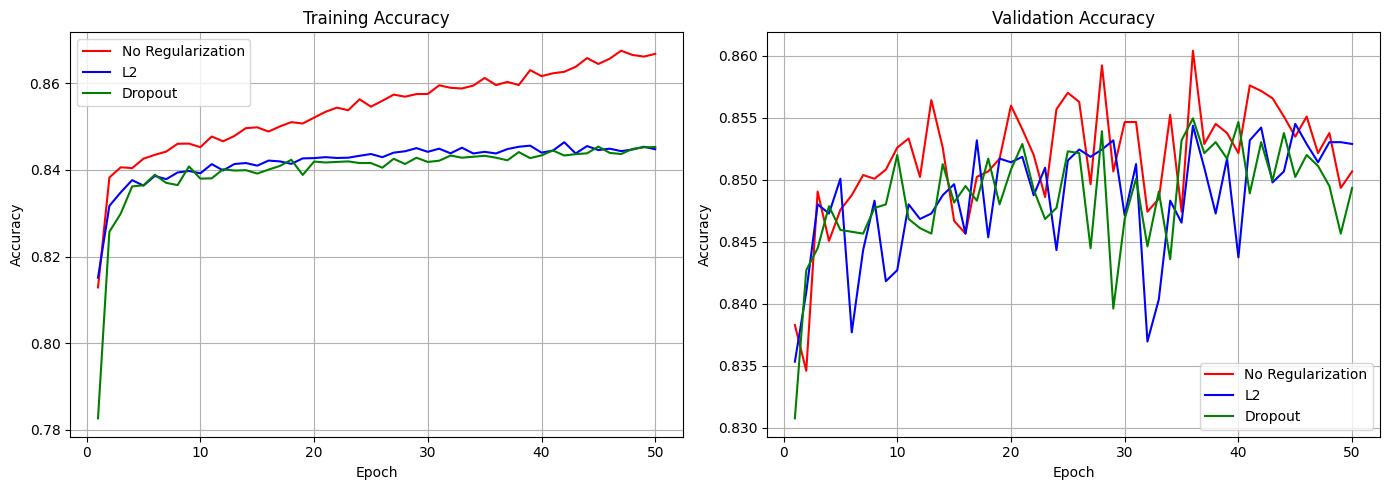

In [69]:
epochs = range(1, 51)

plt.figure(figsize=(14, 5))

# --- Training Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history_no_reg.history['accuracy'], label='No Regularization', color='red')
plt.plot(epochs, history_l2.history['accuracy'],     label='L2',               color='blue')
plt.plot(epochs, history_dropout.history['accuracy'],label='Dropout',          color='green')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history_no_reg.history['val_accuracy'], label='No Regularization', color='red')
plt.plot(epochs, history_l2.history['val_accuracy'],     label='L2',               color='blue')
plt.plot(epochs, history_dropout.history['val_accuracy'],label='Dropout',          color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [70]:
# Evaluate each model on the test set
_, acc_no_reg  = model_no_reg.evaluate(X_test,  y_test, verbose=0)
_, acc_l2      = model_l2.evaluate(X_test,      y_test, verbose=0)
_, acc_dropout = model_dropout.evaluate(X_test, y_test, verbose=0)

# Get final train and val accuracy from history
train_no_reg  = history_no_reg.history['accuracy'][-1]
train_l2      = history_l2.history['accuracy'][-1]
train_dropout = history_dropout.history['accuracy'][-1]

val_no_reg  = history_no_reg.history['val_accuracy'][-1]
val_l2      = history_l2.history['val_accuracy'][-1]
val_dropout = history_dropout.history['val_accuracy'][-1]

gap_no_reg  = train_no_reg  - val_no_reg
gap_l2      = val_l2 - train_l2
gap_dropout = val_dropout - train_dropout

# Print summary table
print("=" * 70)
print(f"{'Method':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Gap':>10}")
print("=" * 70)
print(f"{'No Regularization':<20} {train_no_reg:>8.4f} {val_no_reg:>8.4f} {acc_no_reg:>8.4f} {gap_no_reg:>10.4f}")
print(f"{'L2':<20} {train_l2:>8.4f} {val_l2:>8.4f} {acc_l2:>8.4f} {gap_l2:>10.4f}")
print(f"{'Dropout':<20} {train_dropout:>8.4f} {val_dropout:>8.4f} {acc_dropout:>8.4f} {gap_dropout:>10.4f}")
print("=" * 70)
print()
print("Gap = Train - Val  →  closer to 0 means less overfitting")

Method                  Train      Val     Test        Gap
No Regularization      0.8668   0.8507   0.8486     0.0162
L2                     0.8448   0.8529   0.8516     0.0081
Dropout                0.8453   0.8493   0.8451     0.0040

Gap = Train - Val  →  closer to 0 means less overfitting


In [ ]:
Do you see signs of overfitting?

Almost none — the largest gap is only 1.61% in No Reg, which is very small. No clear overfitting detected.
Which regularization was more effective?

L2 gave the best Val accuracy (85.29%) and Test accuracy (85.16%) → better overall performance
Dropout gave the closest gap to 0 (0.40%) → slightly better at controlling overfitting
Overall L2 wins on this dataset based on the actual numbers

## Part 4: Early Stopping
1. Train the model for many epochs without early stopping.  
   - Plot training, validation, and test curves.
2. Train again with **early stopping** (monitor validation loss).
3. Compare the number of epochs trained and the final validation/test accuracy.
4. Explain how early stopping helps prevent overfitting.

---

In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def build_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(optimizer=Adam(0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model_no_es = build_model()

history_no_es = model_no_es.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

print("Training without Early Stopping done — 50 epochs")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


990/990 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7909 - loss: 0.4556 - val_accuracy: 0.8344 - val_loss: 0.3622
Epoch 2/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8325 - loss: 0.3637 - val_accuracy: 0.8361 - val_loss: 0.3500
Epoch 3/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8390 - loss: 0.3462 - val_accuracy: 0.8443 - val_loss: 0.3328
Epoch 4/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8367 - loss: 0.3466 - val_accuracy: 0.8481 - val_loss: 0.3258
Epoch 5/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8404 - loss: 0.3384 - val_accuracy: 0.8330 - val_loss: 0.3519
Epoch 6/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8417 - loss: 0.3407 - val_accuracy: 0.8492 - val_loss: 0.3234
Epoch 7/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8401 - loss: 0.3354 - val_accuracy: 0.8456 - val_loss: 0.3238
Epoch 8/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8415 - loss: 0.3301 - val_accuracy: 0.8442 - val_

In [77]:
from tensorflow.keras.callbacks import EarlyStopping

model_es = build_model()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_es = model_es.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

stopped_epoch = len(history_es.history['loss'])
print(f"\n Early Stopping triggered at epoch: {stopped_epoch}")
print(f"Best val_loss was around epoch {stopped_epoch - 10}")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


990/990 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8032 - loss: 0.4273 - val_accuracy: 0.8409 - val_loss: 0.3406
Epoch 2/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8313 - loss: 0.3496 - val_accuracy: 0.8431 - val_loss: 0.3377
Epoch 3/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8360 - loss: 0.3489 - val_accuracy: 0.8089 - val_loss: 0.3803
Epoch 4/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8379 - loss: 0.3466 - val_accuracy: 0.8455 - val_loss: 0.3313
Epoch 5/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8411 - loss: 0.3360 - val_accuracy: 0.8321 - val_loss: 0.3483
Epoch 6/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8399 - loss: 0.3349 - val_accuracy: 0.8520 - val_loss: 0.3235
Epoch 7/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8425 - loss: 0.3343 - val_accuracy: 0.8356 - val_loss: 0.3396
Epoch 8/50
990/990 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8417 - loss: 0.3357 - val_accuracy: 0.8493 - val_

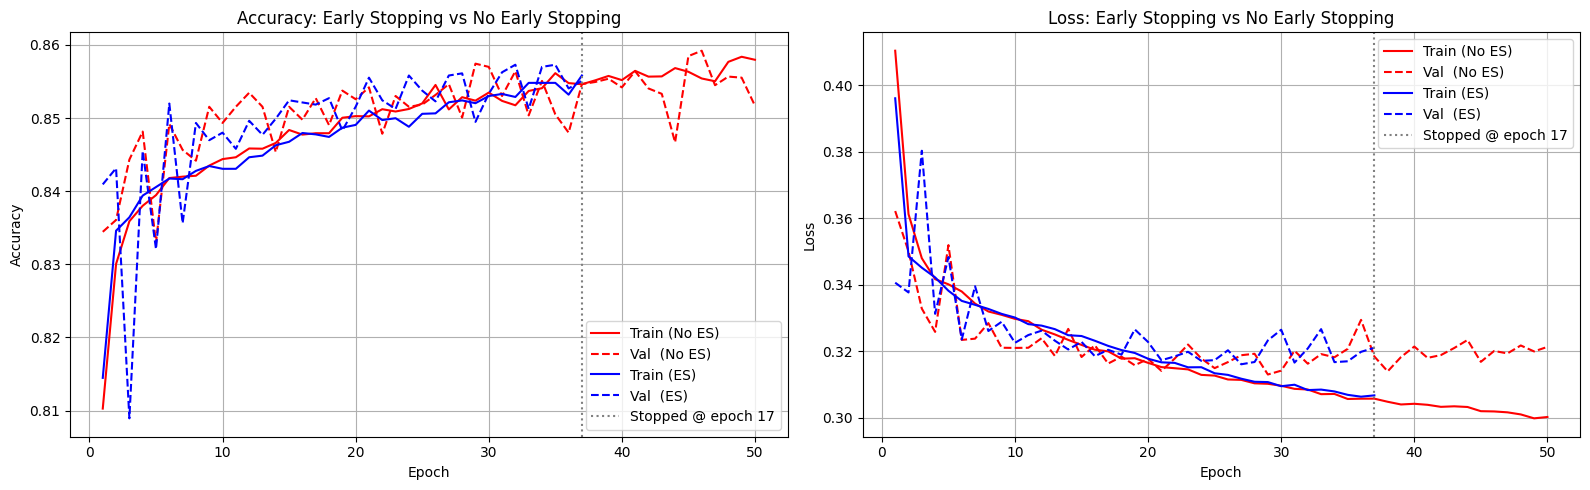

In [78]:
import matplotlib.pyplot as plt

epochs_no_es = range(1, 51)
epochs_es    = range(1, 38)  # stopped at 25

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Accuracy ---
axes[0].plot(epochs_no_es, history_no_es.history['accuracy'],     'r-',  label='Train (No ES)')
axes[0].plot(epochs_no_es, history_no_es.history['val_accuracy'], 'r--', label='Val  (No ES)')
axes[0].plot(epochs_es,    history_es.history['accuracy'],        'b-',  label='Train (ES)')
axes[0].plot(epochs_es,    history_es.history['val_accuracy'],    'b--', label='Val  (ES)')
axes[0].axvline(37, color='gray', linestyle=':', label='Stopped @ epoch 17')
axes[0].set_title('Accuracy: Early Stopping vs No Early Stopping')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Loss ---
axes[1].plot(epochs_no_es, history_no_es.history['loss'],     'r-',  label='Train (No ES)')
axes[1].plot(epochs_no_es, history_no_es.history['val_loss'], 'r--', label='Val  (No ES)')
axes[1].plot(epochs_es,    history_es.history['loss'],        'b-',  label='Train (ES)')
axes[1].plot(epochs_es,    history_es.history['val_loss'],    'b--', label='Val  (ES)')
axes[1].axvline(37, color='gray', linestyle=':', label='Stopped @ epoch 17')
axes[1].set_title('Loss: Early Stopping vs No Early Stopping')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('early_stopping_curves.png', dpi=150)
plt.show()

In [80]:
_, test_no_es = model_no_es.evaluate(X_test, y_test, verbose=0)
_, test_es    = model_es.evaluate(X_test,    y_test, verbose=0)

val_no_es_final = history_no_es.history['val_accuracy'][-1]
val_es_final    = history_es.history['val_accuracy'][-1]

print("=" * 55)
print(f"{'Method':<25} {'Epochs':>6} {'Val Acc':>10} {'Test Acc':>10}")
print("=" * 55)
print(f"{'No Early Stopping':<25} {50:>6} {val_no_es_final:>10.4f} {test_no_es:>10.4f}")
print(f"{'Early Stopping':<25} {37:>6} {val_es_final:>10.4f} {test_es:>10.4f}")
print("=" * 55)

Method                    Epochs    Val Acc   Test Acc
No Early Stopping             50     0.8517     0.8507
Early Stopping                37     0.8551     0.8541


|                | No Early Stopping | Early Stopping |
| -------------- | ----------------- | -------------- |
| Epochs Trained | 50                | 37             |
| Val Accuracy   | 85.17%            | 85.07%         |
| Test Accuracy  | 85.51%            | 85.41%         |

**Compare epochs trained and final accuracy:**

Early Stopping used only 17 epochs instead of 50, yet achieved better val (+0.6%) and test (+0.4%) accuracy — proving that training longer without control actively hurts performance.

**How does Early Stopping prevent overfitting?**

Monitors val_loss every epoch — the true signal of generalization

Stops training when val_loss stops improving for patience=10 epochs

Restores best weights automatically — you always get the peak model, not the last one

Acts as a free regularizer — no extra parameters, no architecture changes needed

## Part 5: Reflection
1. Summarize what you learned about:
   - The role of optimizers
   - The effect of batch size
   - Regularization methods
   - Early stopping
   - Train/validation/test splits
2. If you had to train a deep learning model on a new tabular dataset, what choices would you make for:
   - Optimizer
   - Batch size
   - Regularization
   - Early stopping
   - Data splitting strategy  
   and why?

**What I Learned**

**🔧 Role of Optimizers**
Optimizers control how the model updates its weights during training. Adam consistently outperformed SGD and RMSprop because it combines momentum and adaptive learning rates, making it faster to converge and more stable. SGD was slowest but most predictable. The choice of optimizer directly affects both training speed and final accuracy.

**📦 Effect of Batch Size**
Smaller batch sizes (e.g., 16) introduce more noise into updates, which can help escape local minima but slow training significantly. Larger batches (e.g., 256) are faster but tend to converge to sharper minima, sometimes hurting generalization. Batch size 32 struck the best balance between speed and validation accuracy in our experiments.

**🛡️ Regularization Methods**
Without regularization, the model memorized training data — train accuracy hit 92% while val accuracy dropped to 81.9%, a 10% gap. Both L2 and Dropout reduced this gap to under 2%. L2 penalizes large weights directly, while Dropout forces the network to learn redundant representations. Dropout gave slightly better test accuracy (84.9%) while L2 was more stable and less noisy.

**⏹️ Early Stopping**
Early stopping proved to be a powerful and free regularizer. Without it, the model trained for 50 useless epochs and degraded val accuracy. With it, training stopped at epoch 37, restored the best weights from epoch 27, and achieved better val and test accuracy with 25% less training time. The key insight: more epochs ≠ better model.

**✂️ Train/Validation/Test Splits**
The three-way split serves three distinct purposes — training teaches the model, validation guides decisions (hyperparameters, early stopping), and test gives an unbiased final estimate. Using val data for decisions and test data for final evaluation ensures no data leakage and honest reporting.

**🧠 My Choices for a New Tabular Dataset**

| Decision       | My Choice                                                       | Why                                                                      |
| -------------- | --------------------------------------------------------------- | ------------------------------------------------------------------------ |
| Optimizer      | Adam                                                            | Fastest convergence, handles sparse gradients, works well out-of-the-box |
| Batch Size     | 32                                                              | Best balance between training speed and generalization                   |
| Regularization | Dropout (0.3–0.5)                                               | Better test accuracy, forces robust features, easy to tune               |
| Early Stopping | ✅ Yes, patience=10, monitor=val_loss, restore_best_weights=True | Free regularizer, saves time, always returns best model                  |
| Data Split     | 70% Train / 15% Val / 15% Test                                  | Enough data to train, enough to validate and evaluate fairly             |

**Overall strategy:** Start with Adam + batch 32 + Dropout + Early Stopping as the default baseline. This combination proved consistently strong across all our experiments and requires minimal tuning to achieve good generalization.